# linear regression using gradient descent

1. Explain what X and y represent.
2. Convert the data to numpy arrays

x يمثل مساحة البيت بالمتر المربع input

y يمثل سعر البيت  بالآلاف target


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([50, 60, 70, 80, 90], dtype=float)
y = np.array([150, 180, 210, 240, 270], dtype=float)

x, y

(array([50., 60., 70., 80., 90.]), array([150., 180., 210., 240., 270.]))

In [2]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []

    def fit(self, x, y):
        n = len(x)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * x
            error = y_pred - y

            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

            d_theta_0 = (2 / n) * np.sum(error)
            d_theta_1 = (2 / n) * np.sum(error * x)

            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

        return self

    def predict(self, x):
        return self.theta_0 + self.theta_1 * x

    def mse(self, x, y):
        y_pred = self.predict(x)
        return np.mean((y_pred - y) ** 2)

    def plot_training(self, x, y, title_suffix=""):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].plot(range(1, self.n_iters + 1), self.sse_history, color="tab:blue")
        axes[0].set_xlabel("iteration")
        axes[0].set_ylabel("sse")
        axes[0].set_title("sse over iterations" + title_suffix)

        axes[1].scatter(x, y, color="tab:orange", label="data")
        axes[1].plot(x, self.predict(x), color="tab:blue", label="regression line")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")
        axes[1].set_title("regression line" + title_suffix)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

In [3]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(x, y)

print("theta_0:", model.theta_0)
print("theta_1:", model.theta_1)

theta_0: -1.0055957901462392e+95
theta_1: -7.326427288635144e+96


What do theta_0 and theta_1 represent in the regression equation?

  y = theta_0 + theta_1 * x

theta_0  is the intercept 

theta_1   is the slope 

In [4]:
size = 70
predicted_price = model.predict(np.array([size]))[0]
print(f"predicted price for {size} m2: {predicted_price:.2f} thousand")

predicted price for 70 m2: -512950469783474681601735659150059764001133837647853304062802627266710541831899364891863753559113728.00 thousand


2. Print the predicted value.
Question:
Is the prediction reasonable based on the dataset? Why?

لا مش منطقي هنا والسبب مش في المنطق الرياضي للموديل لكن في اختيار learning_rate بالنسبة لمقياس x بما ان x قيمها كبيرة نسبيا (50 لـ90) بدون تطبيع الـ gradient بيبقى ضخم فالخطوة الاولى نفسها بتخرج theta_1 برا النطاق المعقول وبعد كام iteration السعر المتوقع بيبقى رقم كبير مالوش اي علاقة بالبيانات لو استخدمنا نفس الموديل على x بعد normalization 

## 5. visualization

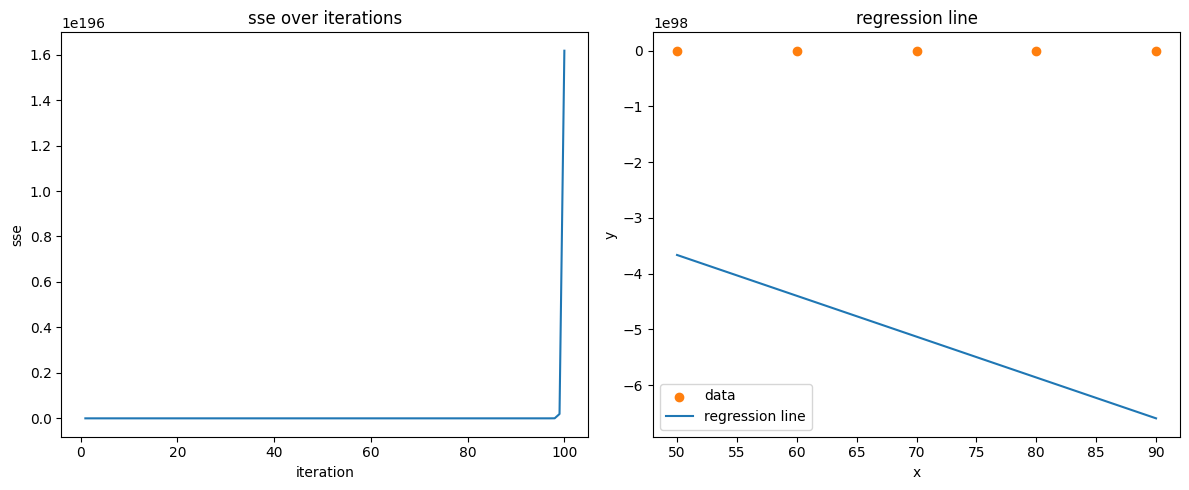

In [5]:
model.plot_training(x, y)

 Why SSE decrease over time
With a suitable learning rate, each Gradient Descent step updates θ₀ and θ₁ in the direction that reduces the SSE so the error gradually decreases with each iteration.
What convergence mean in Gradient Descent
Convergence means that θ₀ and θ₁ become almost stable with very small changes between iterations This means the model has reached a point close to the minimum SSE



In [6]:
large_lr_model = LinearRegressionGD(learning_rate=0.01, n_iters=100)
large_lr_model.fit(x, y)

small_lr_model = LinearRegressionGD(learning_rate=0.0001, n_iters=100)
small_lr_model.fit(x, y)

print("learning_rate=0.01 final sse:", large_lr_model.sse_history[-1])
print("learning_rate=0.001 final sse:", model.sse_history[-1])
print("learning_rate=0.0001 final sse:", small_lr_model.sse_history[-1])

learning_rate=0.01 final sse: inf
learning_rate=0.001 final sse: 1.6170789775172399e+196
learning_rate=0.0001 final sse: 0.00033181560776546876


/tmp/ipykernel_565/1292373695.py:15: RuntimeWarning: overflow encountered in square
  sse = np.sum(error ** 2)


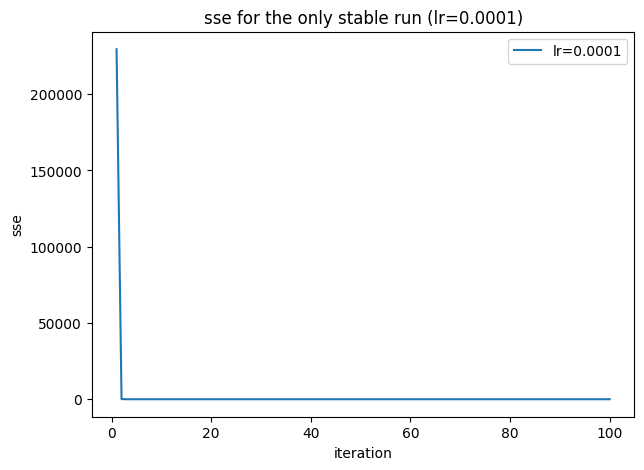

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1, 101), small_lr_model.sse_history, label="lr=0.0001")
ax.set_xlabel("iteration")
ax.set_ylabel("sse")
ax.set_title("sse for the only stable run (lr=0.0001)")
ax.legend()
plt.show()

Question: What happens if the learning rate is too large?

If the learning rate is too large, the model takes steps that are too big causing θ₀ and θ₁ to overshoot the minimum As a result SSE increases instead of decreasing and the model may diverge instead of converging


In [8]:
print("mse:", model.mse(x, y))

mse: 2.7385349181421895e+197


theta_0: 38.100971015430154
theta_1: 7.697558564229364
final sse: 154393.80298957668
predicted price for 70 m2: 38.100971015430154


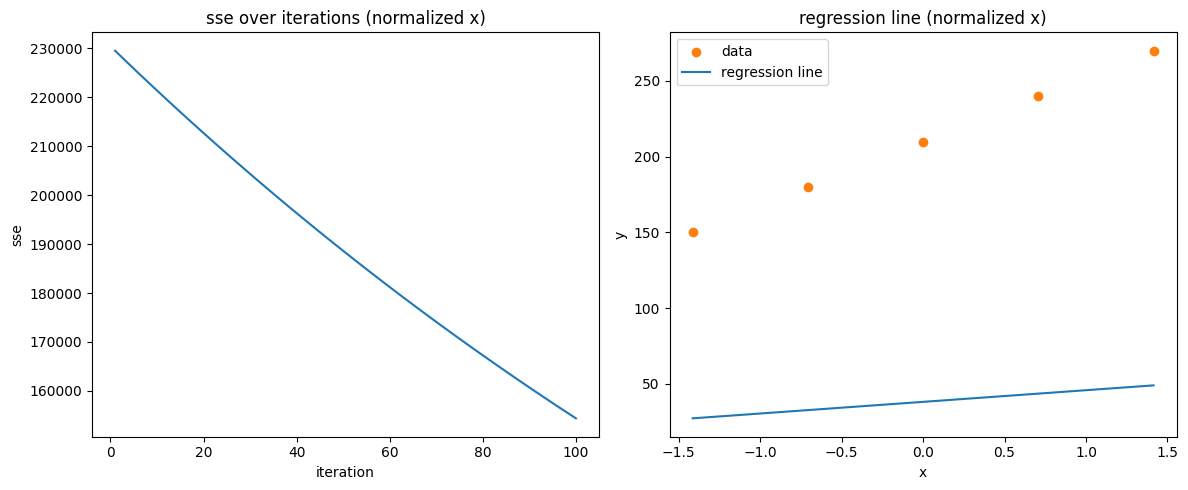

In [9]:
x_mean = x.mean()
x_std = x.std()
x_norm = (x - x_mean) / x_std

norm_model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
norm_model.fit(x_norm, y)

print("theta_0:", norm_model.theta_0)
print("theta_1:", norm_model.theta_1)
print("final sse:", norm_model.sse_history[-1])

size_norm = (size - x_mean) / x_std
print("predicted price for 70 m2:", norm_model.predict(np.array([size_norm]))[0])

norm_model.plot_training(x_norm, y, title_suffix=" (normalized x)")

After normalization, the same learning rate (0.001) becomes stable and SSE decreases over the iterations instead of exploding 
